100%|██████████| 9.91M/9.91M [00:00<00:00, 86.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 45.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 53.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.76MB/s]


Epoch 1, Loss: 12449.0684
Epoch 2, Loss: 11312.5020
Epoch 3, Loss: 10470.4424


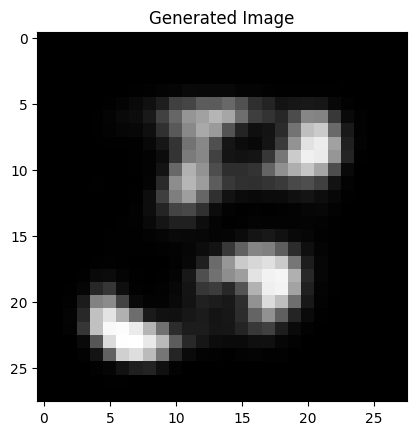

In [1]:
# VAE Implementation

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Dataset
transform = transforms.ToTensor()

dataset = datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

loader = DataLoader(dataset, batch_size=128, shuffle=True)

# VAE Model
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, 20)
        self.fc22 = nn.Linear(400, 20)

        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))

        return self.fc21(h), self.fc22(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc3(z))

        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        return self.decode(z), mu, logvar

model = VAE()

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Loss
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(
        recon_x,
        x.view(-1, 784),
        reduction='sum'
    )

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD

# Training
for epoch in range(3):
    for images, _ in loader:
        images = images.view(-1, 784)

        recon, mu, logvar = model(images)

        loss = loss_function(recon, images, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# Visualization
with torch.no_grad():
    sample = torch.randn(64, 20)

    generated = model.decode(sample).view(-1, 28, 28)

plt.imshow(generated[0], cmap='gray')
plt.title("Generated Image")
plt.show()